Data generated by Todd is missing alpha's and delta's for intermediate potentials - probably to keep data clean and accurate and not get bogged down by experimental error <br>
I am going to calculate my own kinetic parameters and cross verify with Todd's data by plotting <br>
Experimental parameters: <br>
KOH concs: 0.1, 0.25, 0.5, 1 (M) <br>
CO Pressure: 0.1, 1, 10, 100 <br>
16 different conditions for PtRu KOH oxidation <br>
Potential ranges: 0.5 - 1 (vs RHE) <br>
Catalyst: Pt50Ru50 (edit sheet name to Pt66Ru33 for other catalyst) <br>
<br>
Units: <br>
Potential: V vs RHE <br>
Current: mA/cm2 <br>
<br>
Data was interpolated (Pchipinterpolation) to put all data sets on the same grid. <br>
Data is truncated at alpha minimum to remove current affected by oxidized surface (formation of extra oxidized species like O*). <br>
Untruncated data saved separately for plotting purposes. <br>

# Initialization

In [2]:
import pandas as pd
import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from scipy.signal import savgol_filter

import sys
import os 

utils_path = r"C:\Users\awast\OneDrive\Desktop\MKM"
data_path = r"C:\Users\awast\OneDrive\Desktop\MKM\CO_oxidation"
if utils_path not in sys.path: sys.path.append(utils_path)
import _utils

In [ ]:
# Experimental conditions (PtRu KOH) and constants

alloy = 'Pt50Ru50'
alloy_condition = 'Pt50Ru50 KOH'

C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
conditions = list(itertools.product(C_KOH_list, P_CO_list))
conditions_delta_CO = list(itertools.product(C_KOH_list, P_CO_list[0:-1]))

R, T, F = 8.3145, 293.15, 96485
n = 2 # number of electrons transferred in the reaction

number_of_points = 58 # For a dE of 0.01 V = 10 mV

# Set to 0 to cut exactly at min alpha (current behavior)
# Set to an integer (e.g., 10) to include 10 points after the peak
# Set to None to include ALL data (no truncation)
buffer_after_min = 0

gamma = 210e-6 / F # moles of Pt per cm2, 1cm2 Pt = 210 uC 

In [4]:
# Load current density data from 4 Excel files

current_densities = pd.read_excel(os.path.join(data_path, 'Summary_current_densities.xlsx'), sheet_name=alloy_condition)
alphas_todd_raw = pd.read_excel(os.path.join(data_path, 'Summary_TCs.xlsx'), sheet_name=alloy_condition)
delta_OH_todd_raw = pd.read_excel(os.path.join(data_path, 'Summary_pH_order.xlsx'), sheet_name=alloy_condition)
delta_CO_todd_raw = pd.read_excel(os.path.join(data_path, 'Summary_CO_order.xlsx'), sheet_name=alloy_condition)

experiments = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 2
    subset = current_densities.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'j']
    # Force numeric, coerce bad values to NaN, then drop
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['j'] = pd.to_numeric(subset['j'], errors='coerce')
    subset = subset.dropna()
    experiments[(C_KOH, P_CO)] = subset

# Smoothing and Interpolating

In [5]:
# Block 4: Interpolate to a consistent SHE grid and calculate kinetics

# 1. Establish the master SHE grid (Consistent dE spacing like Pt100)
all_min_SHE = min(df['E'].min() - 0.0592 * (14 + np.log10(C)) for (C, P), df in experiments.items())
all_max_SHE = max(df['E'].max() - 0.0592 * (14 + np.log10(C)) for (C, P), df in experiments.items())

dE = (all_max_SHE - all_min_SHE) / (number_of_points - 1)
master_E_grid = np.arange(np.floor(all_min_SHE/dE)*dE, np.ceil(all_max_SHE/dE)*dE + dE, dE)

experiments_interp = {}
untruncated_data = {}

for P_CO in P_CO_list:
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        
        # Local RHE bounds for this specific condition
        df = experiments[condition]
        local_min_RHE = df['E'].min()
        local_max_RHE = df['E'].max()
        
        # Convert to SHE and align to master grid
        E_ref = -0.0592 * (14 + np.log10(C_KOH))
        mask = (master_E_grid >= (local_min_RHE + E_ref) - 1e-9) & (master_E_grid <= (local_max_RHE + E_ref) + 1e-9)
        E_grid_SHE = master_E_grid[mask]
        
        # Interpolate current
        j_interp = PchipInterpolator(df['E'] + E_ref, df['j'])(E_grid_SHE)
        
        # Calculate rate
        rate_interp = j_interp / (1000 * n * F * gamma)
        log_rate_interp = np.log(rate_interp)
        
        # Smoothen data (SG - commented out for now)
        # j_smooth = savgol_filter(j_interp, window_length=11, polyorder=3)

        # Calculate alpha
        alpha = (R * T / F) * np.gradient(log_rate_interp, E_grid_SHE)
        
        # Find truncation point (Skipping first 5 points to avoid baseline noise artifacts)
        buffer_pts = buffer_after_min if buffer_after_min is not None else 0
        if buffer_after_min is not None and len(alpha) > 5:
            cutoff_idx = np.argmin(alpha[5:]) + 5 + buffer_pts
        else:
            cutoff_idx = len(E_grid_SHE)
            
        # Store UNTRUNCATED data for plotting/reaction orders later
        untruncated_data[condition] = {
            'E': E_grid_SHE,
            'j': j_interp,
            'rate': rate_interp,
            'log_rate': log_rate_interp,
            'alpha': alpha
        }
        
        # Store TRUNCATED data for the Bayesian PyTensor model
        experiments_interp[condition] = {
            'E': E_grid_SHE[:cutoff_idx],
            'j': j_interp[:cutoff_idx],
            'rate': rate_interp[:cutoff_idx],
            'log_rate': log_rate_interp[:cutoff_idx],
            'alpha': alpha[:cutoff_idx]
        }

# Currents

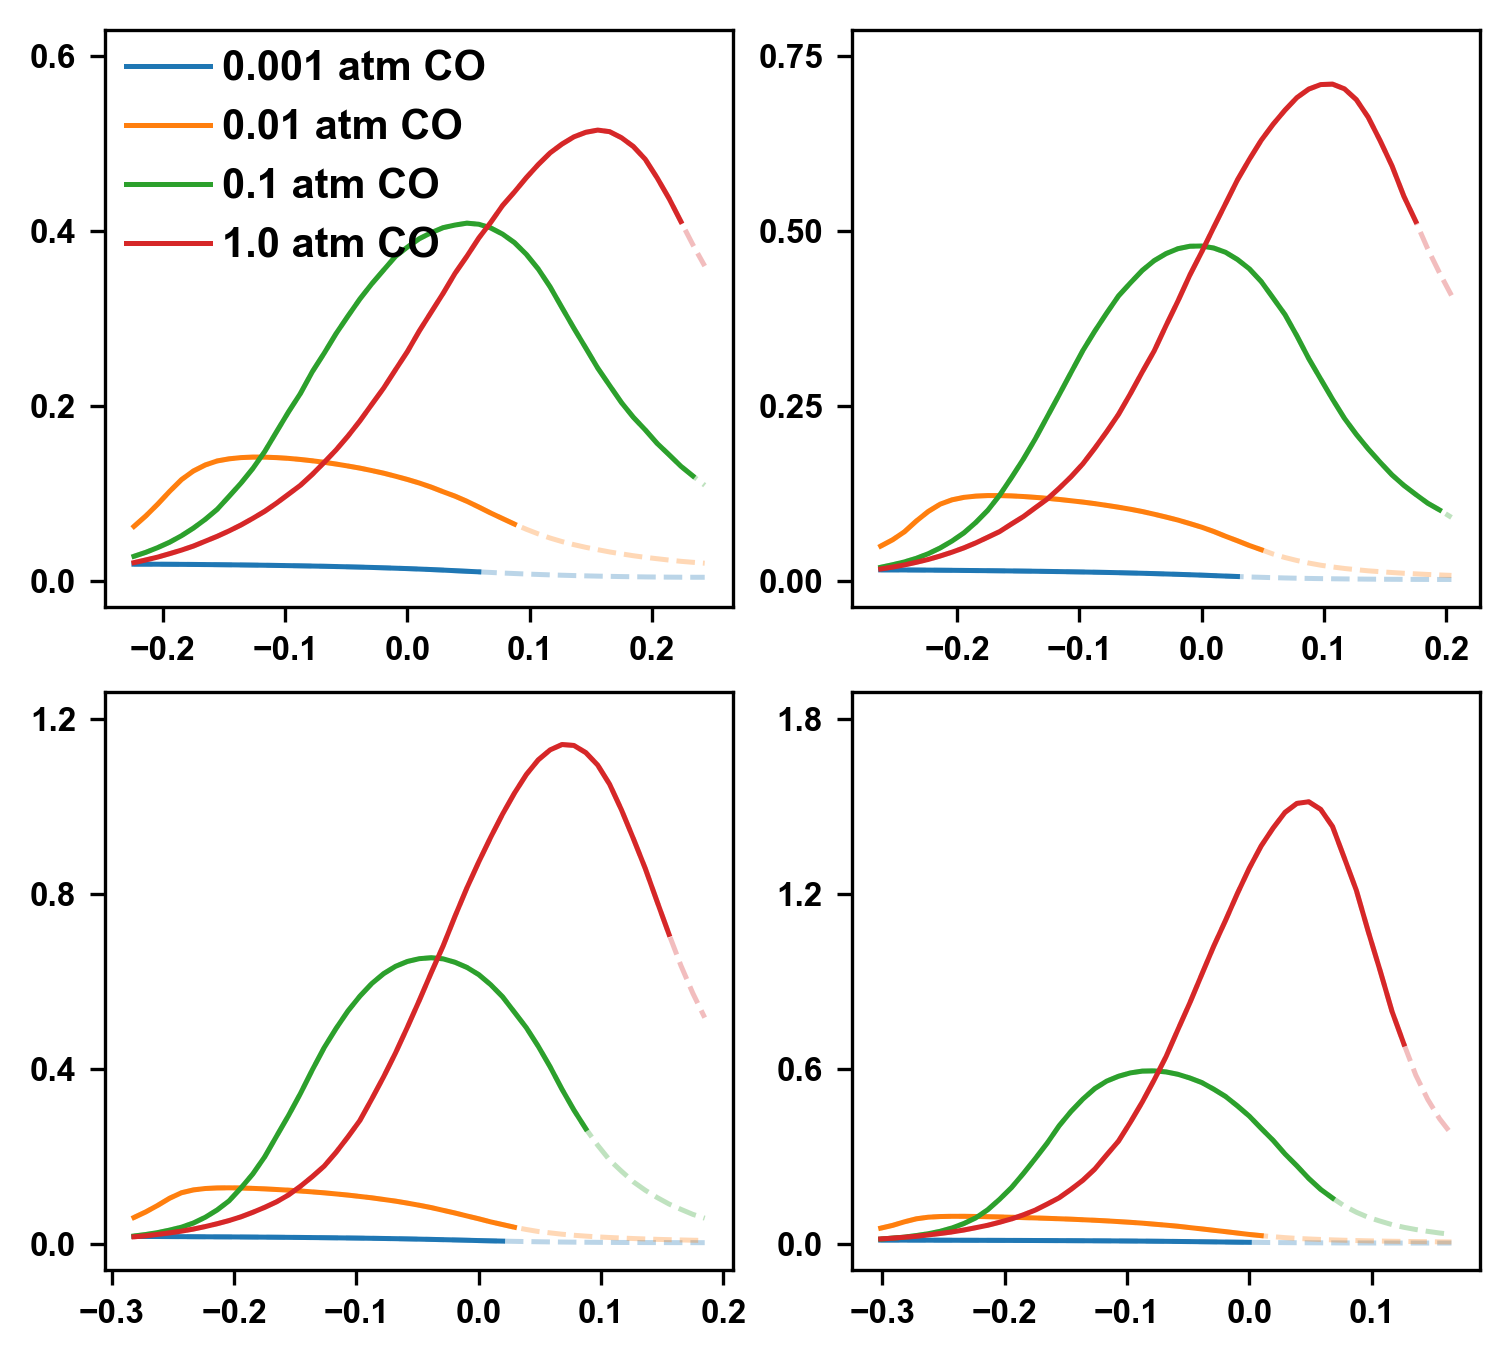

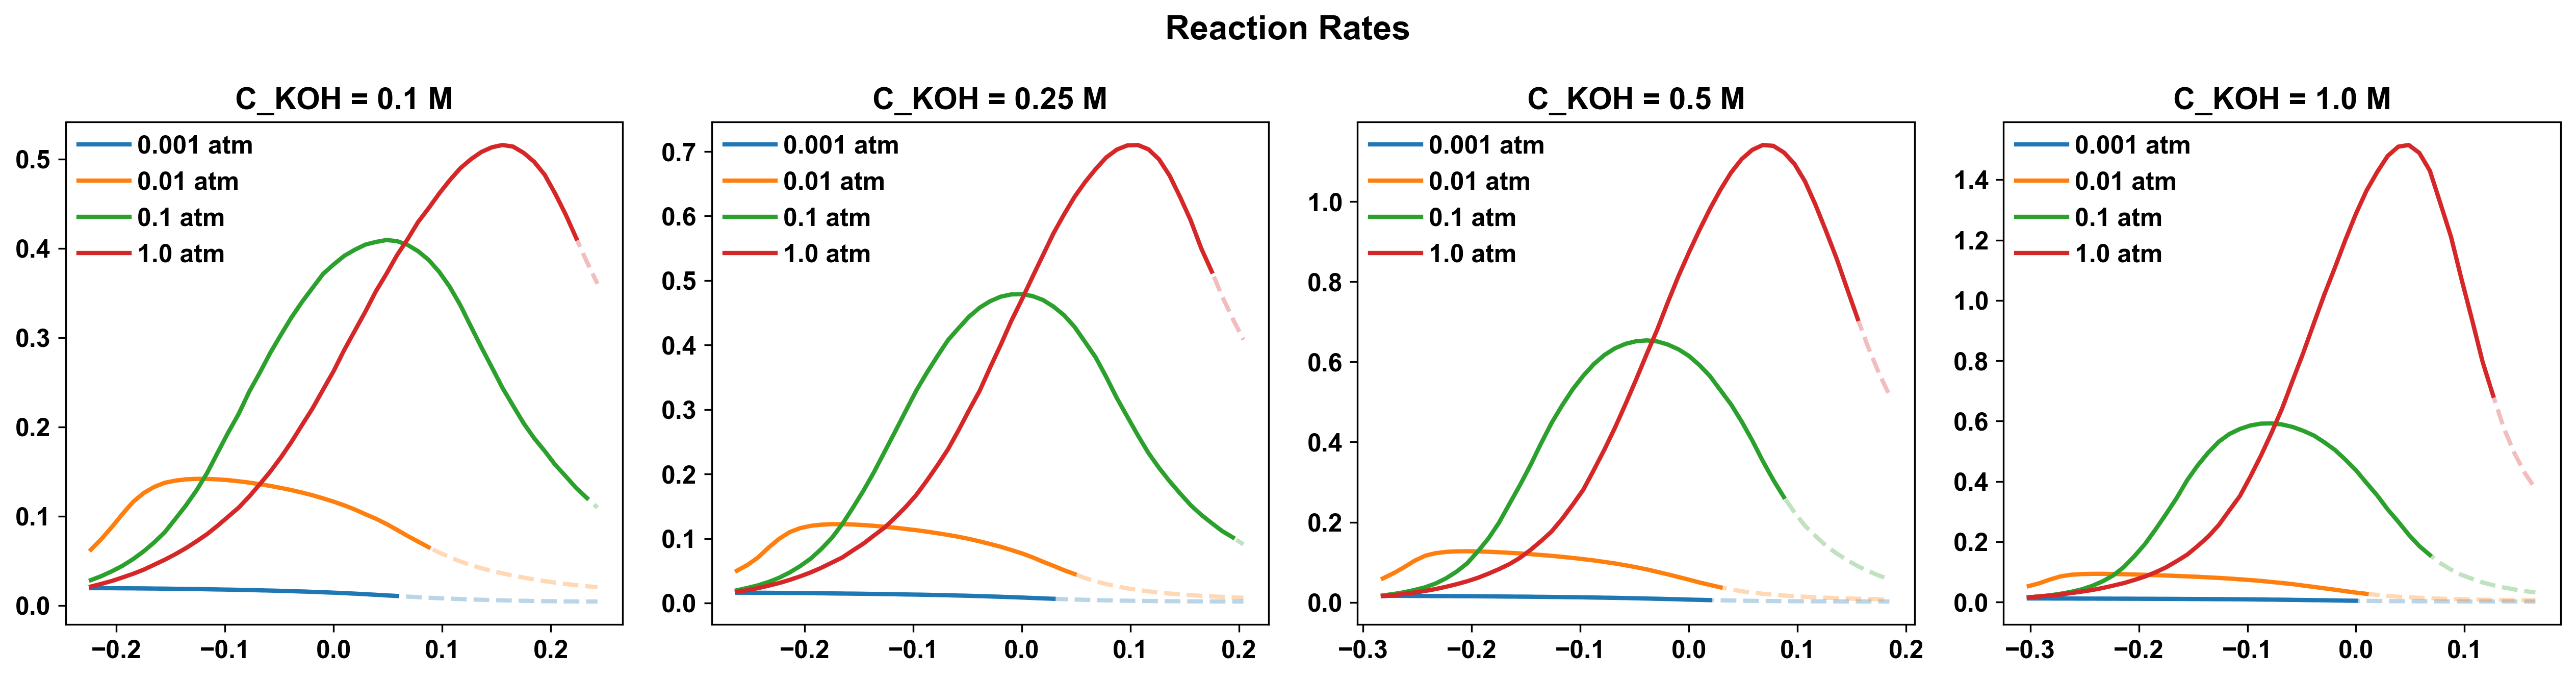

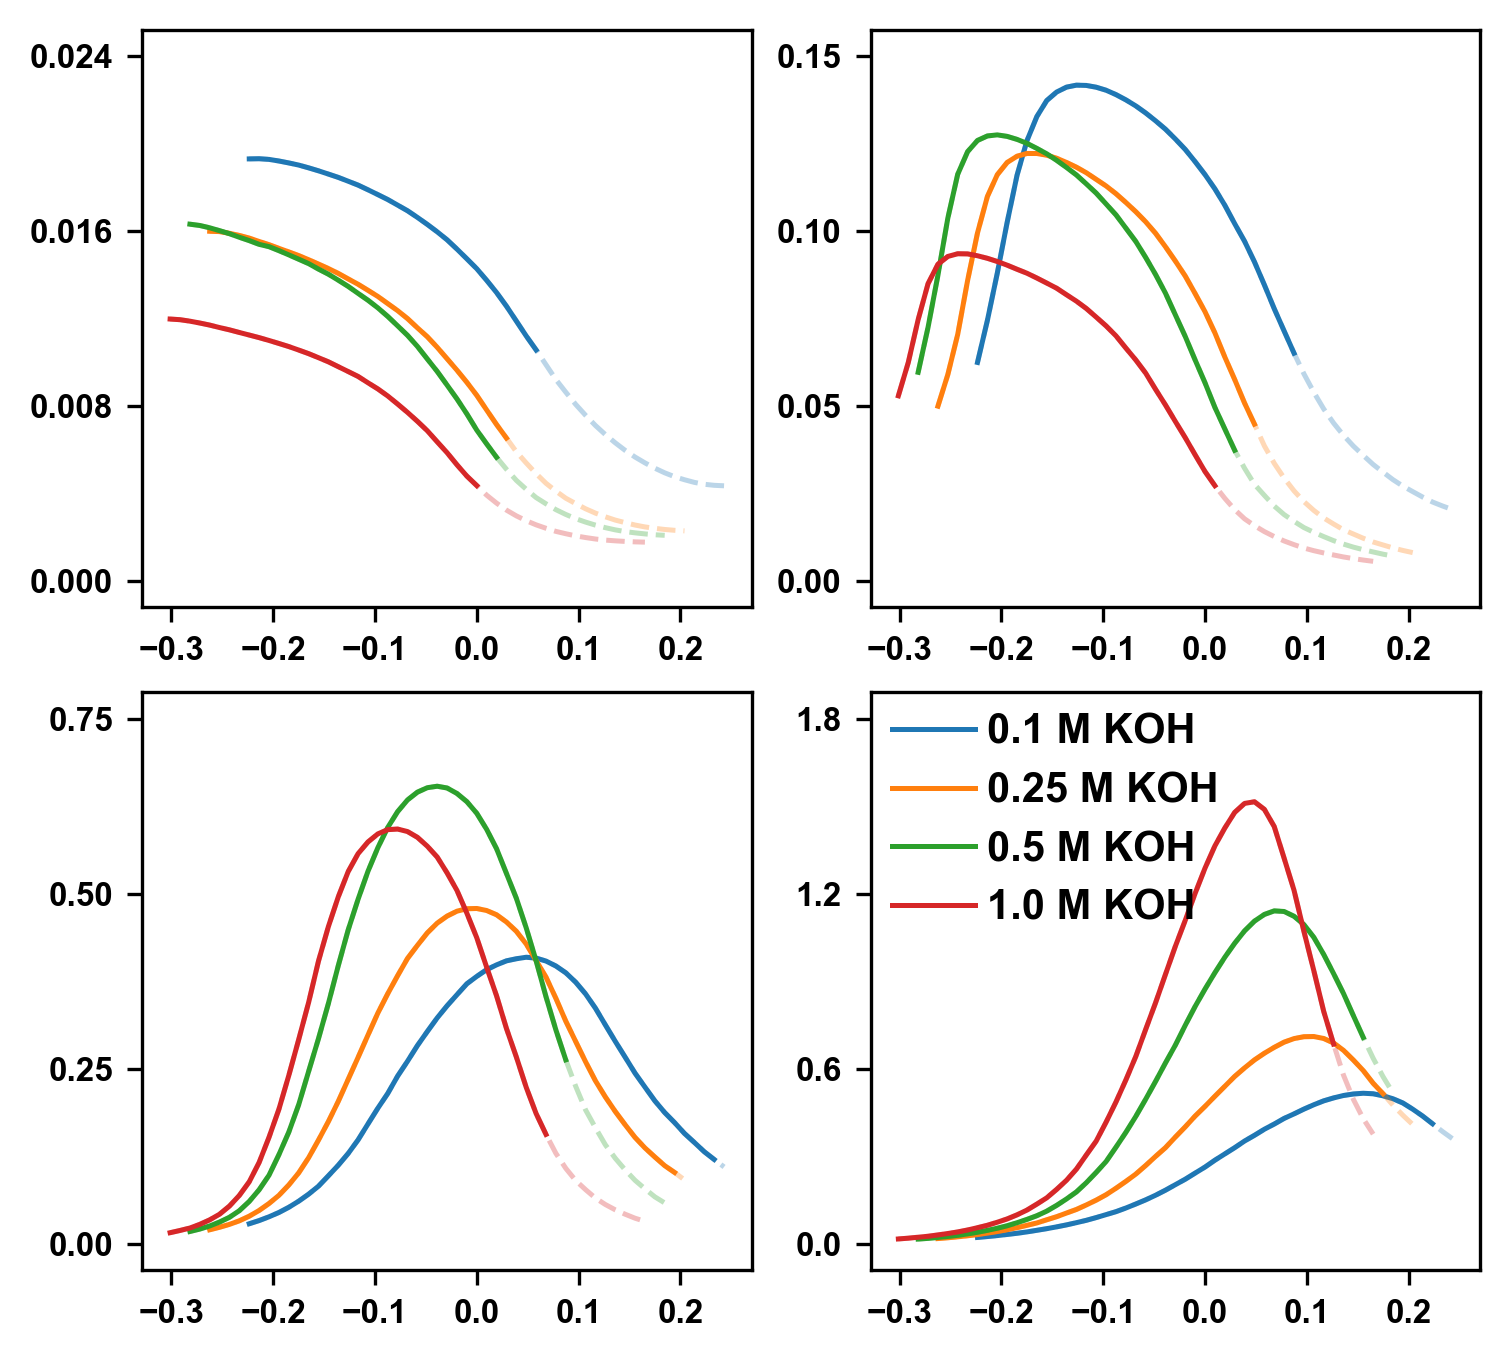

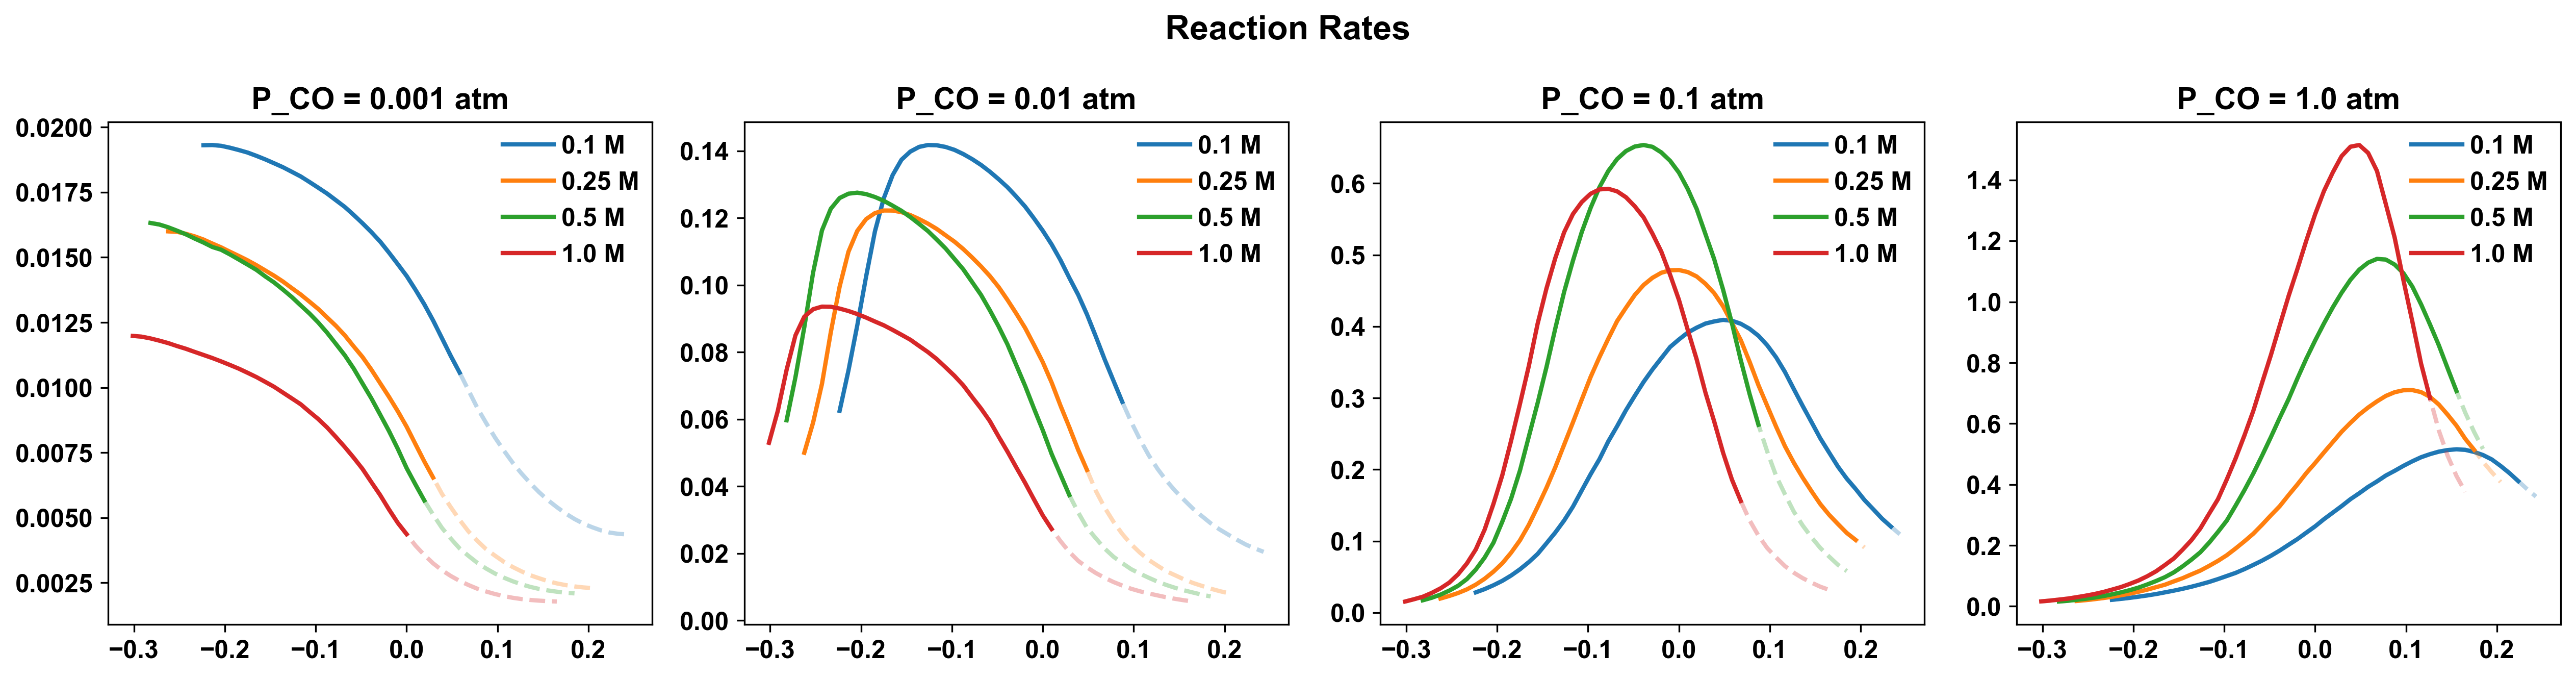

In [6]:
# Block 5: Plotting Reaction Rates (Current Densities)

# --- Plot 1: 2x2 Grid (C_KOH subplots, P_CO lines) ---
fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1)
    max_y = 0
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = experiments_interp[condition]['E']
        rate = experiments_interp[condition]['rate']
        E_untrunc = untruncated_data[condition]['E']
        rate_untrunc = untruncated_data[condition]['rate']
        
        line, = ax.plot(E, rate, label=f'{P_CO} atm CO', linewidth=1.2)
        ax.plot(E_untrunc, rate_untrunc, color=line.get_color(), alpha=0.3, linestyle='--', linewidth=1.2)
        
        max_y = max(max_y, np.max(rate_untrunc))    
        
    mag = 10 ** np.floor(np.log10(max_y / 3))
    norm_step = (max_y / 3) / mag
    nice_step = 1 if norm_step <= 1 else 1.5 if norm_step <= 1.5 else 2 if norm_step <= 2 else 2.5 if norm_step <= 2.5 else 3 if norm_step <= 3 else 4 if norm_step <= 4 else 5 if norm_step <= 5 else 6 if norm_step <= 6 else 8 if norm_step <= 8 else 10
    step = nice_step * mag
    max_tick = 3 * step
    margin = 0.05 * max_tick
    
    ax.set_yticks([0, step, 2 * step, max_tick])
    ax.set_ylim(-margin, max_tick + margin)
    ax.tick_params(axis='both', labelsize=8)
    if i == 0: ax.legend(fontsize=10, frameon=False, loc='upper left')
plt.tight_layout(pad=0.5)
plt.show()

# --- Plot 2: 1x4 Grid (C_KOH subplots, P_CO lines) ---
fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Reaction Rates', fontsize=16, fontweight='bold')
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1)
    plt.title(f'C_KOH = {C_KOH} M')
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = experiments_interp[condition]['E']
        rate = experiments_interp[condition]['rate']
        E_untrunc = untruncated_data[condition]['E']
        rate_untrunc = untruncated_data[condition]['rate']
        
        line, = ax.plot(E, rate, label=f'{P_CO} atm', linewidth=2)
        ax.plot(E_untrunc, rate_untrunc, color=line.get_color(), alpha=0.3, linestyle='--')
    plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: 2x2 Grid (P_CO subplots, C_KOH lines) ---
fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, P_CO in enumerate(P_CO_list):
    ax = plt.subplot(2, 2, i + 1)
    max_y = 0
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        E = experiments_interp[condition]['E']
        rate = experiments_interp[condition]['rate']
        E_untrunc = untruncated_data[condition]['E']
        rate_untrunc = untruncated_data[condition]['rate']
        
        line, = ax.plot(E, rate, label=f'{C_KOH} M KOH', linewidth=1.2)
        ax.plot(E_untrunc, rate_untrunc, color=line.get_color(), alpha=0.3, linestyle='--', linewidth=1.2)
        max_y = max(max_y, np.max(rate_untrunc))    
        
    mag = 10 ** np.floor(np.log10(max_y / 3))
    norm_step = (max_y / 3) / mag
    nice_step = 1 if norm_step <= 1 else 1.5 if norm_step <= 1.5 else 2 if norm_step <= 2 else 2.5 if norm_step <= 2.5 else 3 if norm_step <= 3 else 4 if norm_step <= 4 else 5 if norm_step <= 5 else 6 if norm_step <= 6 else 8 if norm_step <= 8 else 10
    step = nice_step * mag
    max_tick = 3 * step
    margin = 0.05 * max_tick
    
    ax.set_yticks([0, step, 2 * step, max_tick])
    ax.set_ylim(-margin, max_tick + margin)
    ax.tick_params(axis='both', labelsize=8)
    if i == 3: ax.legend(fontsize=10, frameon=False, loc='upper left')
plt.tight_layout(pad=0.5)
plt.show()

# --- Plot 4: 1x4 Grid (P_CO subplots, C_KOH lines) ---
fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Reaction Rates', fontsize=16, fontweight='bold')
for i, P_CO in enumerate(P_CO_list):
    ax = plt.subplot(1, 4, i + 1) 
    plt.title(f'P_CO = {P_CO} atm')
    for C_KOH in C_KOH_list:
        condition = (C_KOH, P_CO)
        E = experiments_interp[condition]['E']
        rate = experiments_interp[condition]['rate']
        E_untrunc = untruncated_data[condition]['E']
        rate_untrunc = untruncated_data[condition]['rate']
        
        line, = ax.plot(E, rate, label=f'{C_KOH} M', linewidth=2)
        ax.plot(E_untrunc, rate_untrunc, color=line.get_color(), alpha=0.3, linestyle='--')
    plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Block 6: Load Todd's alpha data + classification

alpha_todd = {}
for i, (C_KOH, P_CO) in enumerate(conditions):
    col_idx = i * 2
    subset = alphas_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'alpha'] # currently in RHE
    
    # Force numeric and drop bad values (Excel safety check)
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['alpha'] = pd.to_numeric(subset['alpha'], errors='coerce')
    subset = subset.dropna()
    
    # Convert E to SHE BEFORE putting it into the dictionary
    E_ref = -0.0592 * (14 + np.log10(C_KOH))
    subset['E'] = subset['E'] + E_ref
    
    alpha_todd[(C_KOH, P_CO)] = subset

# Transfer Coefficients

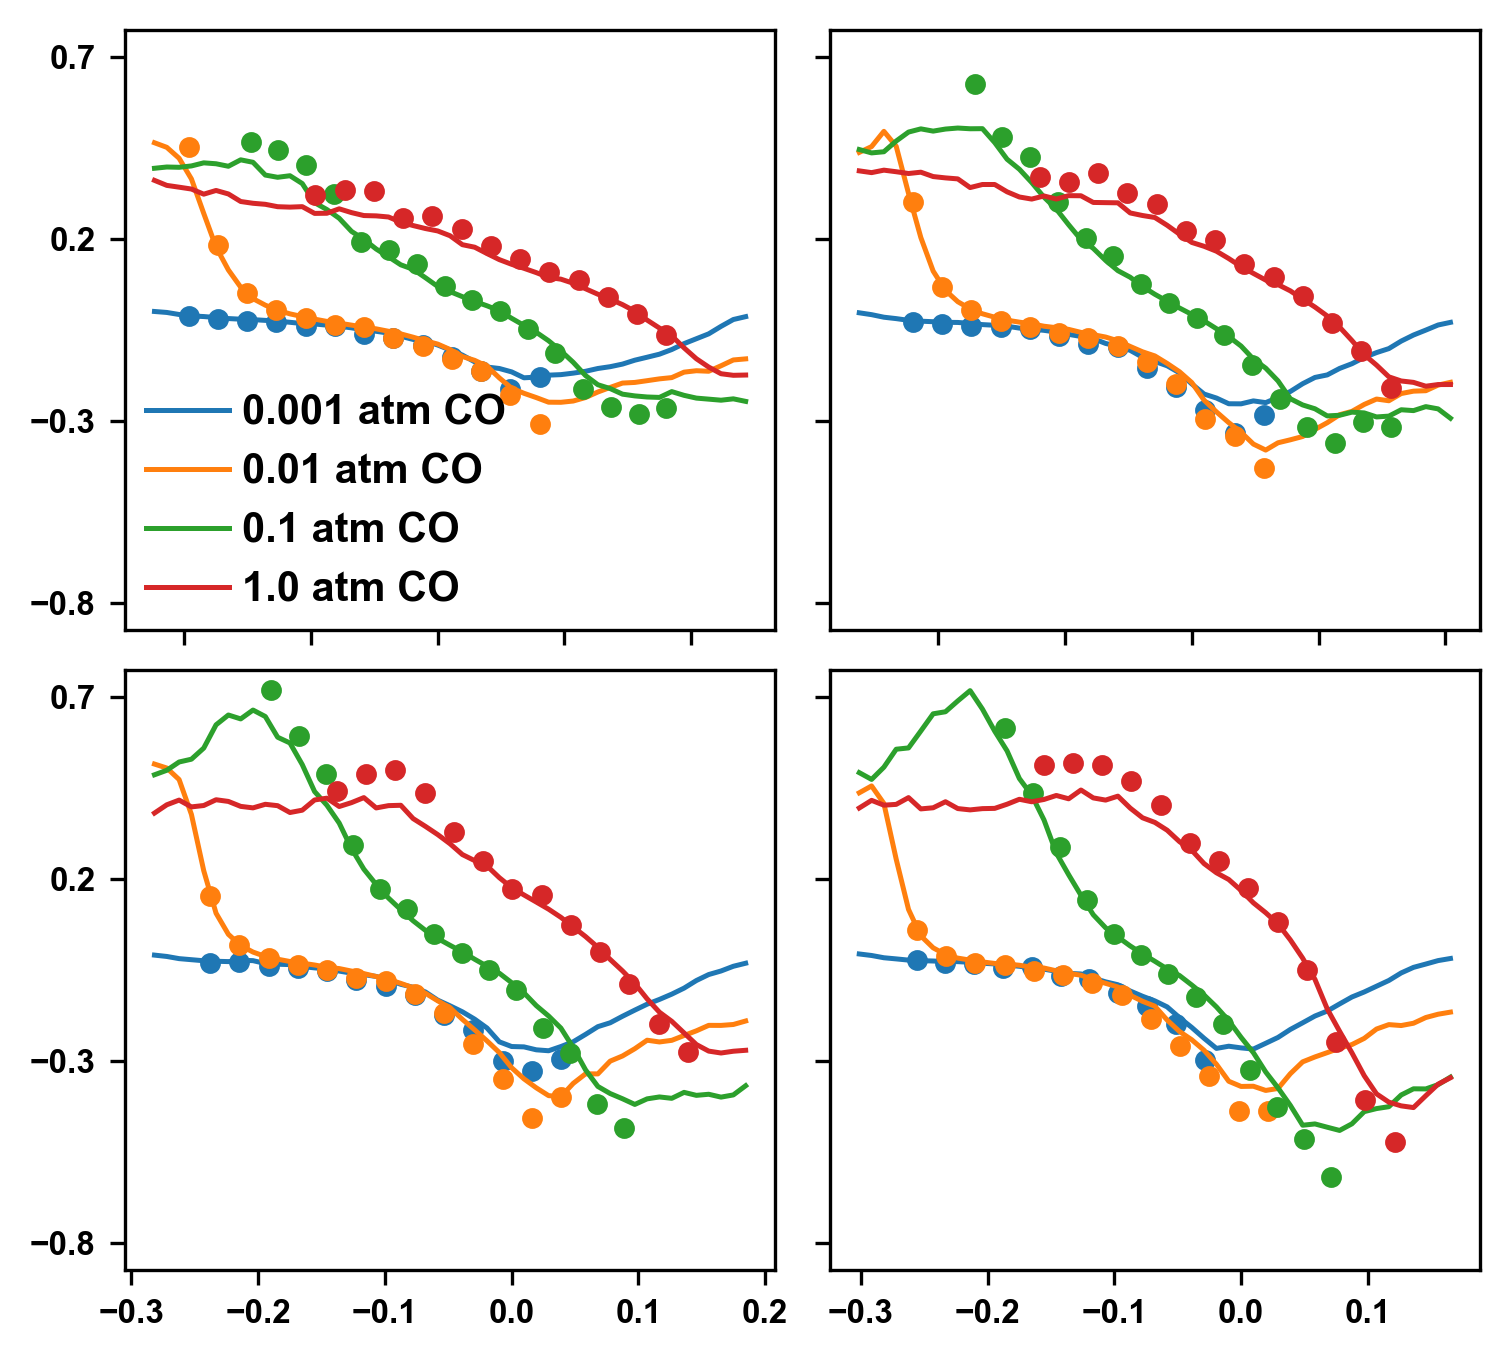

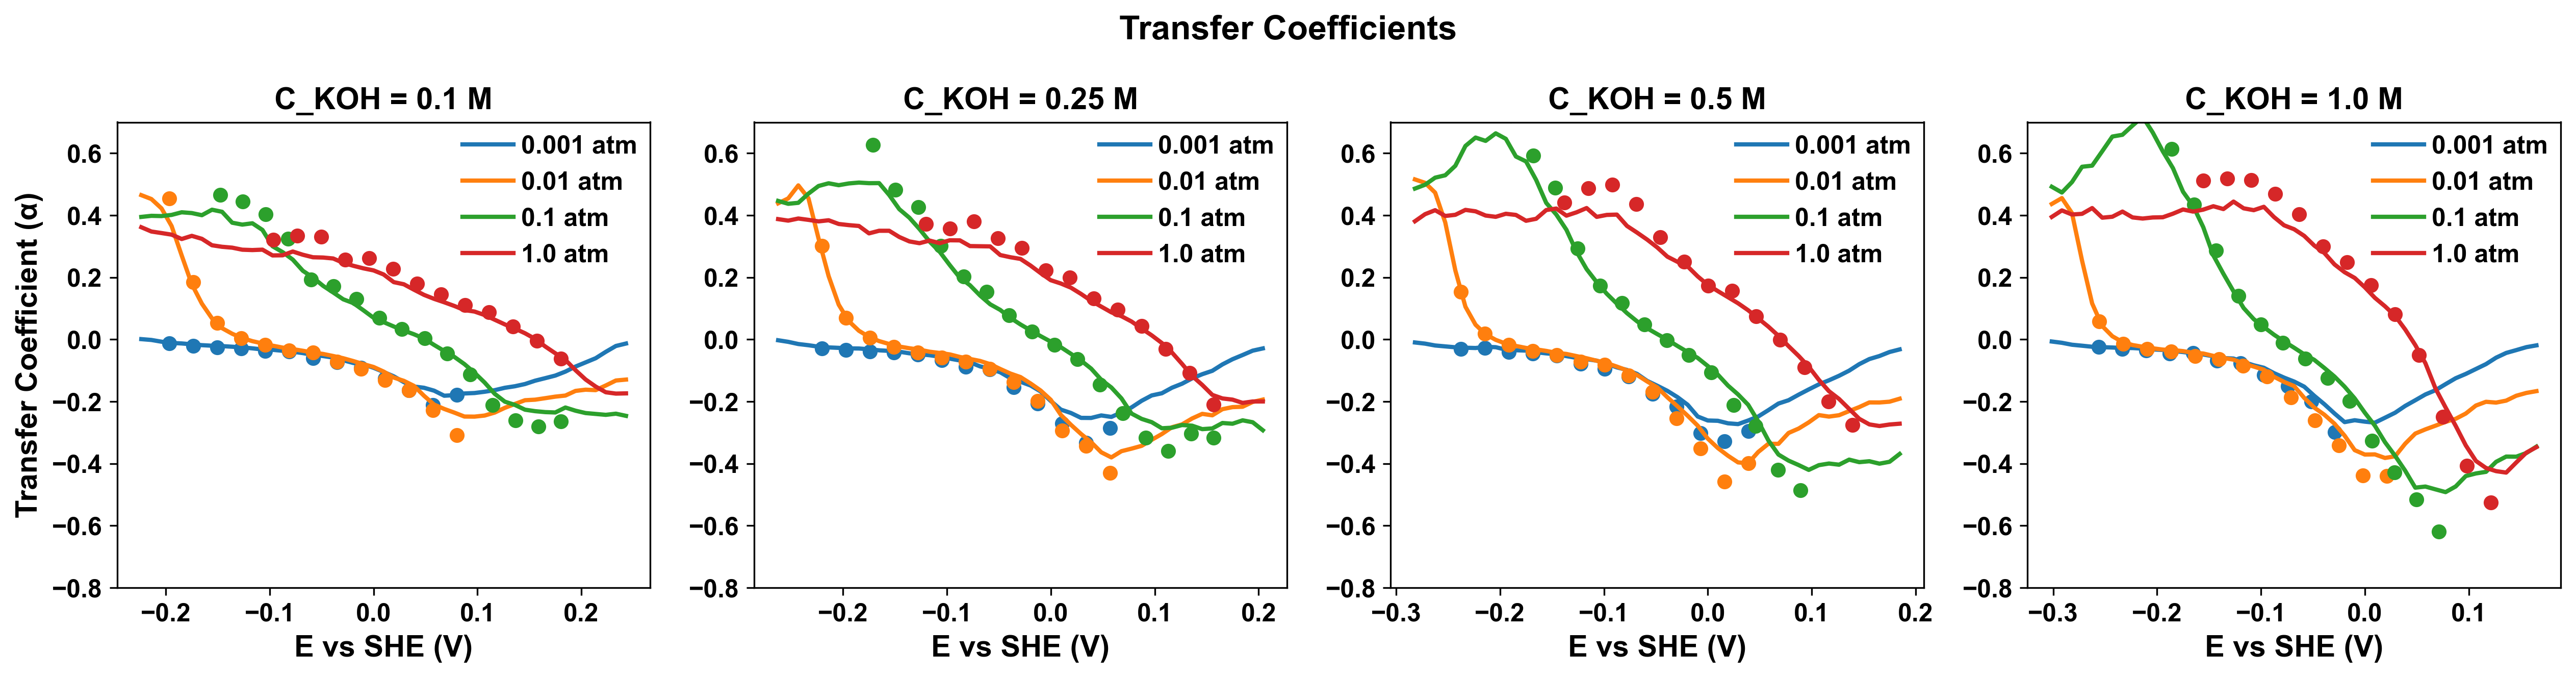

In [8]:
# Plotting alphas 

# --- Plot 1: 2x2 Grid (C_KOH subplots, P_CO lines) ---
fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1) 
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = untruncated_data[condition]['E'] 
        alpha = untruncated_data[condition]['alpha'] 
        line = ax.plot(E, alpha, label=f'{P_CO} atm CO', linewidth=1.2)
        
        # Todd's discrete points (No SD since no replicates)
        if condition in alpha_todd and not alpha_todd[condition].empty:
            E_todd = alpha_todd[condition]['E']
            alpha_todd_val = alpha_todd[condition]['alpha']
            ax.plot(E_todd, alpha_todd_val, 'o', markersize=4, color=line[0].get_color())
        
    span = 0.7 - (-0.8)
    margin = 0.05 * span
    
    ax.set_yticks([-0.8, -0.3, 0.2, 0.7])
    ax.set_ylim(-0.8 - margin, 0.7 + margin)
    ax.tick_params(axis='both', labelsize=8)
    
    # Clean up inner tick labels for the 2x2 grid
    if i < 2: ax.tick_params(labelbottom=False)
    if i % 2 != 0: ax.tick_params(labelleft=False)
    
    if i == 0: ax.legend(fontsize=10, frameon=False, loc='lower left')

plt.tight_layout(pad=0.5)
plt.show()


# --- Plot 2: 1x4 Grid (C_KOH subplots, P_CO lines) ---
fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('Transfer Coefficients', fontsize=16, fontweight='bold')
for i, C_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1) 
    plt.title(f'C_KOH = {C_KOH} M') 
    for P_CO in P_CO_list:
        condition = (C_KOH, P_CO)
        E = untruncated_data[condition]['E'] 
        alpha = untruncated_data[condition]['alpha'] 
        line = ax.plot(E, alpha, label=f'{P_CO} atm', linewidth=2)
        
        if condition in alpha_todd and not alpha_todd[condition].empty:
            E_todd = alpha_todd[condition]['E']
            alpha_todd_val = alpha_todd[condition]['alpha']
            ax.plot(E_todd, alpha_todd_val, 'o', markersize=6, color=line[0].get_color())
        
    ax.set_ylim(-0.8, 0.7)
    if i == 0: ax.set_ylabel('Transfer Coefficient (α)')
    ax.set_xlabel('E vs SHE (V)')
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Block 7: Load Todd's delta_OH data + classification

delta_OH_todd = {}
for i, P_CO in enumerate(P_CO_list):
    col_idx = i * 2
    subset = delta_OH_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'delta_OH'] # already in SHE
    
    # Force numeric and drop bad values (Excel safety check)
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['delta_OH'] = pd.to_numeric(subset['delta_OH'], errors='coerce')
    subset = subset.dropna()
    
    delta_OH_todd[P_CO] = subset

In [10]:
# Block 8: Calculate delta_OH from current data

for P_CO in P_CO_list:
    # 1. Find the overlapping SHE potentials for all KOH concentrations at this P_CO
    # (We use untruncated_data to get the widest possible overlap)
    overlapping_E = None
    for C_KOH in C_KOH_list:
        E_array = np.round(untruncated_data[(C_KOH, P_CO)]['E'], 5) # Round to avoid float errors
        if overlapping_E is None:
            overlapping_E = set(E_array)
        else:
            overlapping_E = overlapping_E.intersection(E_array)
            
    # Sort the overlapping E grid
    shared_E = np.sort(list(overlapping_E))
    
    # 2. Extract the rates at these specific shared potentials
    rate_matrix = []
    for C_KOH in C_KOH_list:
        E_array = np.round(untruncated_data[(C_KOH, P_CO)]['E'], 5)
        # We can use j or rate here (slope of log is identical), let's use rate
        rate_array = untruncated_data[(C_KOH, P_CO)]['rate'] 
        
        # Mask to keep only the shared E points
        mask = np.isin(E_array, shared_E)
        rate_matrix.append(rate_array[mask])
        
    rate_matrix = np.vstack(rate_matrix)
    
    # 3. Calculate delta_OH (slope of ln(rate) vs ln(C_KOH))
    delta_OH = np.polyfit(np.log(C_KOH_list), np.log(rate_matrix), deg=1)[0]
    
    # 4. Store the shared E and delta_OH for plotting later
    for C_KOH in C_KOH_list:
        untruncated_data[(C_KOH, P_CO)]['shared_E_OH'] = shared_E
        untruncated_data[(C_KOH, P_CO)]['delta_OH'] = delta_OH

# OH Reaction Order

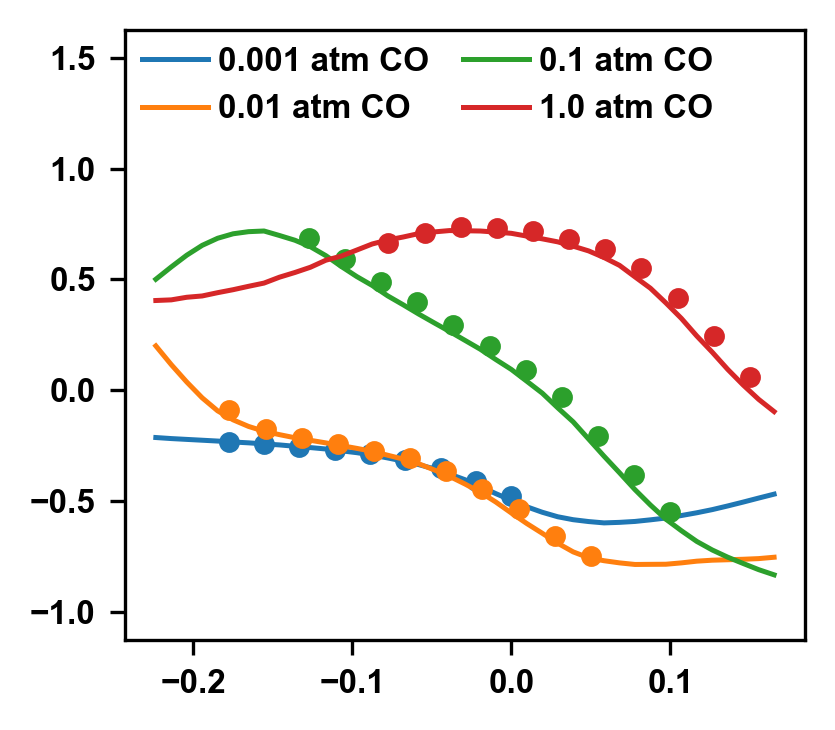

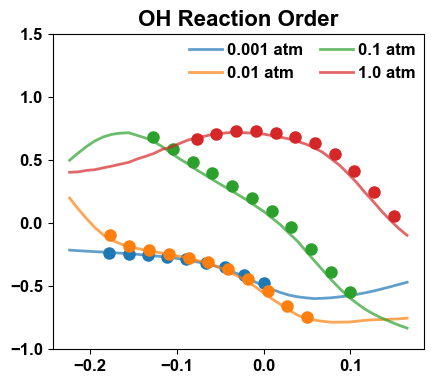

In [11]:
# --- Plot 1: Small Publication Style (2.75 x 2.4) ---
fig = plt.figure(figsize=(2.75, 2.4), dpi=300)
ax = plt.subplot(1, 1, 1)
for P_CO in P_CO_list:
    condition = (C_KOH_list[1], P_CO) # Arbitrary C_KOH to access the stored delta_OH
    delta_OH = untruncated_data[condition]['delta_OH'] 
    E_SHE = untruncated_data[condition]['shared_E_OH'] 
    
    line = ax.plot(E_SHE, delta_OH, label=f'{P_CO} atm CO', linewidth=1.2) 
    
    # Todd's discrete points (No SD since no replicates)
    if P_CO in delta_OH_todd and not delta_OH_todd[P_CO].empty:
        E_todd = delta_OH_todd[P_CO]['E']
        delta_OH_todd_val = delta_OH_todd[P_CO]['delta_OH']
        ax.plot(E_todd, delta_OH_todd_val, 'o', markersize=4, color=line[0].get_color())

span = 1.5 - (-1.0)
margin = 0.05 * span
ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
ax.set_ylim(-1.0 - margin, 1.5 + margin)
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=8, frameon=False, loc='upper left', ncols=2)
plt.tight_layout(pad=0.5)
plt.show()


# --- Plot 2: Medium Exploration Style (4.5 x 4) ---
fig = plt.figure(figsize=(4.5, 4), dpi=100)
plt.title('OH Reaction Order', fontsize=16, fontweight='bold')
for P_CO in P_CO_list:
    condition = (C_KOH_list[1], P_CO)
    delta_OH = untruncated_data[condition]['delta_OH'] 
    E_SHE = untruncated_data[condition]['shared_E_OH']
    
    line, = plt.plot(E_SHE, delta_OH, label=f'{P_CO} atm', alpha=0.7, linewidth=2) 
    
    # Todd's discrete points
    if P_CO in delta_OH_todd and not delta_OH_todd[P_CO].empty:
        E_todd = delta_OH_todd[P_CO]['E']
        delta_OH_todd_val = delta_OH_todd[P_CO]['delta_OH']
        plt.plot(E_todd, delta_OH_todd_val, 'o', markersize=8, color=line.get_color())
        
plt.legend(ncols=2)
plt.ylim(-1, 1.5)
plt.tight_layout()
plt.show()

In [12]:
# Block 10: Load Todd's delta_CO data + classification

delta_CO_todd = {}
for i, (C_KOH, P_CO) in enumerate(conditions_delta_CO):
    col_idx = i * 2
    subset = delta_CO_todd_raw.iloc[3:, col_idx : col_idx+2].copy()
    subset.columns = ['E', 'delta_CO'] # currently in RHE
    
    # Force numeric and drop bad values (Excel safety check)
    subset['E'] = pd.to_numeric(subset['E'], errors='coerce')
    subset['delta_CO'] = pd.to_numeric(subset['delta_CO'], errors='coerce')
    subset = subset.dropna()
    
    # Convert E to SHE BEFORE putting it into the dictionary
    E_ref = -0.0592 * (14 + np.log10(C_KOH))
    subset['E'] = subset['E'] + E_ref
    
    delta_CO_todd[(C_KOH, P_CO)] = subset

In [13]:
# Block 11: Calculate delta_CO from current data

for (C_KOH, P_CO) in conditions_delta_CO:
    condition = (C_KOH, P_CO)
    
    # Find the next P_CO for the 2-point calculation
    idx = int(np.where(P_CO_list == P_CO)[0][0])
    P_CO_next = P_CO_list[idx + 1]
    
    # Extract potentials and round to avoid float matching errors
    E_1 = np.round(untruncated_data[(C_KOH, P_CO)]['E'], 5)
    E_2 = np.round(untruncated_data[(C_KOH, P_CO_next)]['E'], 5)
    
    # Find the exact overlapping potential grid
    shared_E = np.sort(list(set(E_1).intersection(set(E_2))))
    
    # Create masks to extract the exact matching rates (j)
    mask_1 = np.isin(E_1, shared_E)
    mask_2 = np.isin(E_2, shared_E)
    
    rate_1 = untruncated_data[(C_KOH, P_CO)]['rate'][mask_1]
    rate_2 = untruncated_data[(C_KOH, P_CO_next)]['rate'][mask_2]
    
    # Calculate delta_CO (two-point finite difference of log-log)
    delta_CO = (np.log(rate_2) - np.log(rate_1)) / (np.log(P_CO_next) - np.log(P_CO))
    
    # Store the results securely
    untruncated_data[condition]['delta_CO'] = delta_CO
    untruncated_data[condition]['shared_E_CO'] = shared_E

# CO Reaction Order

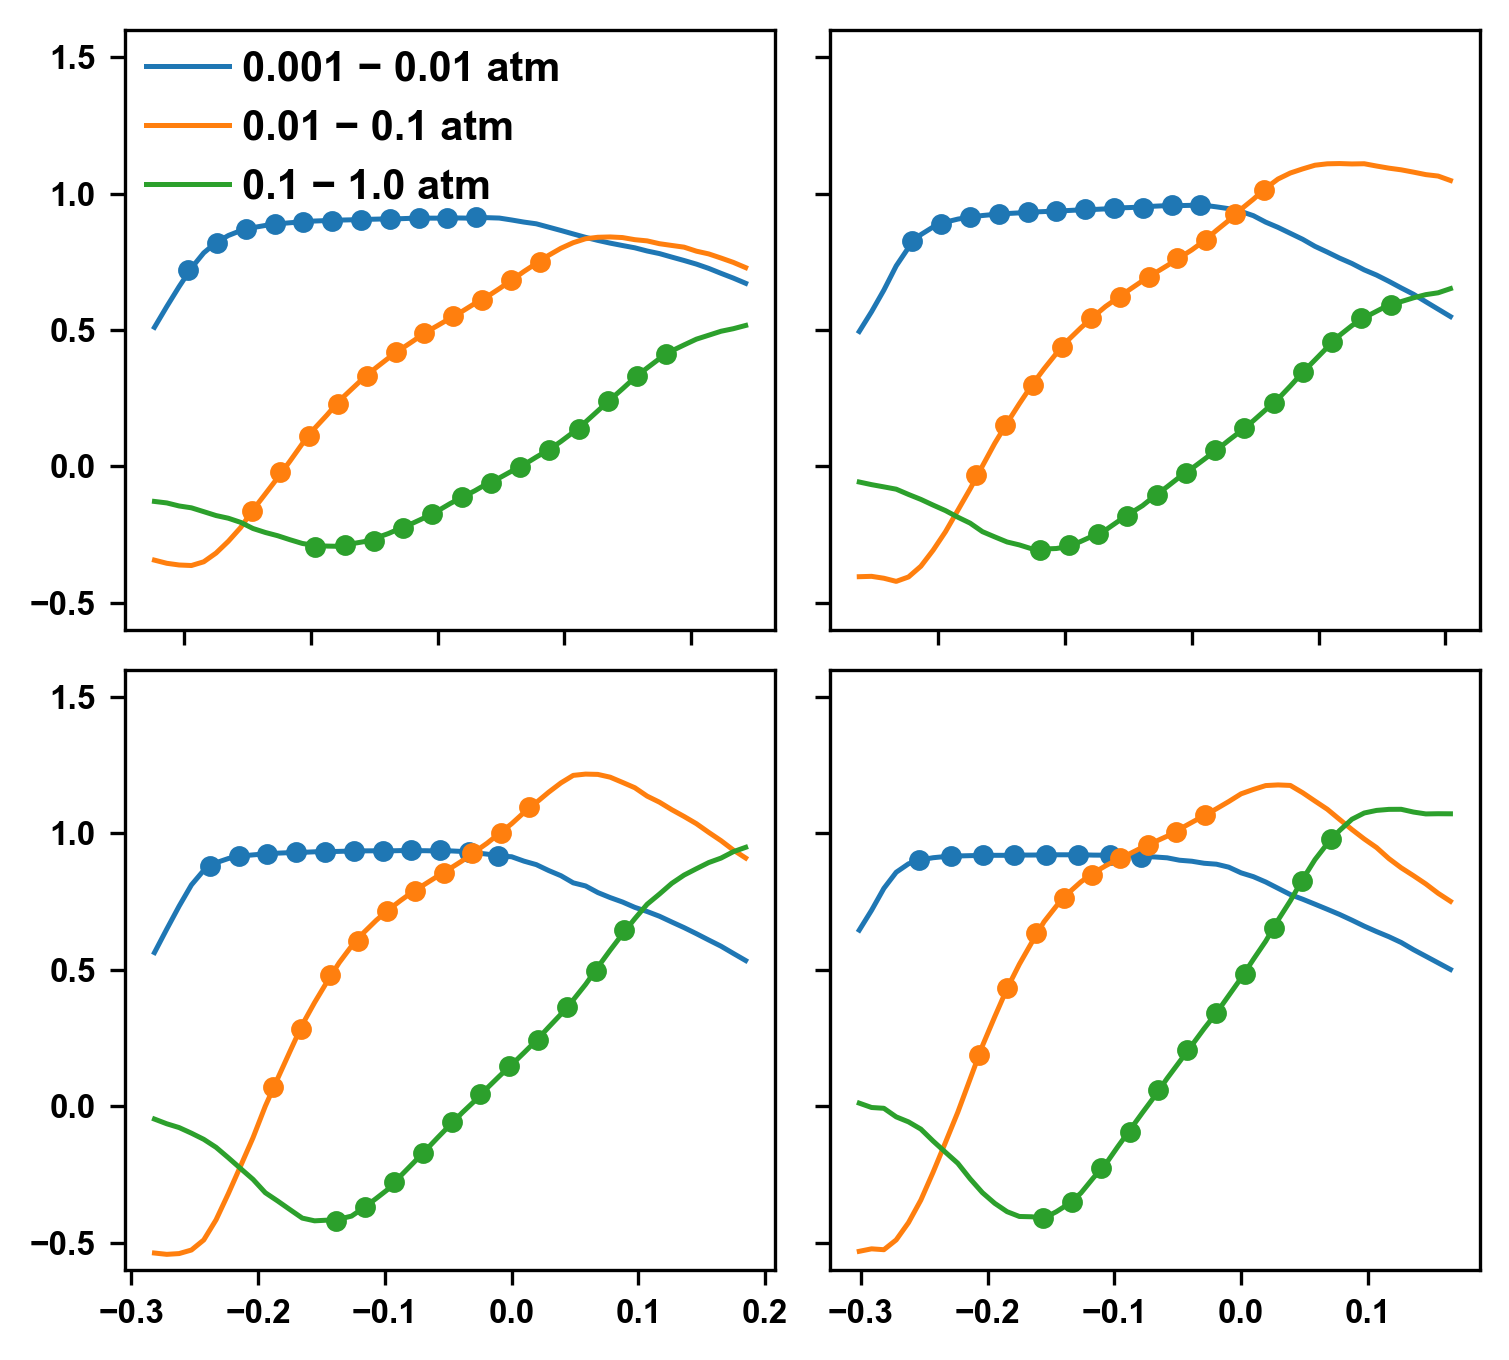

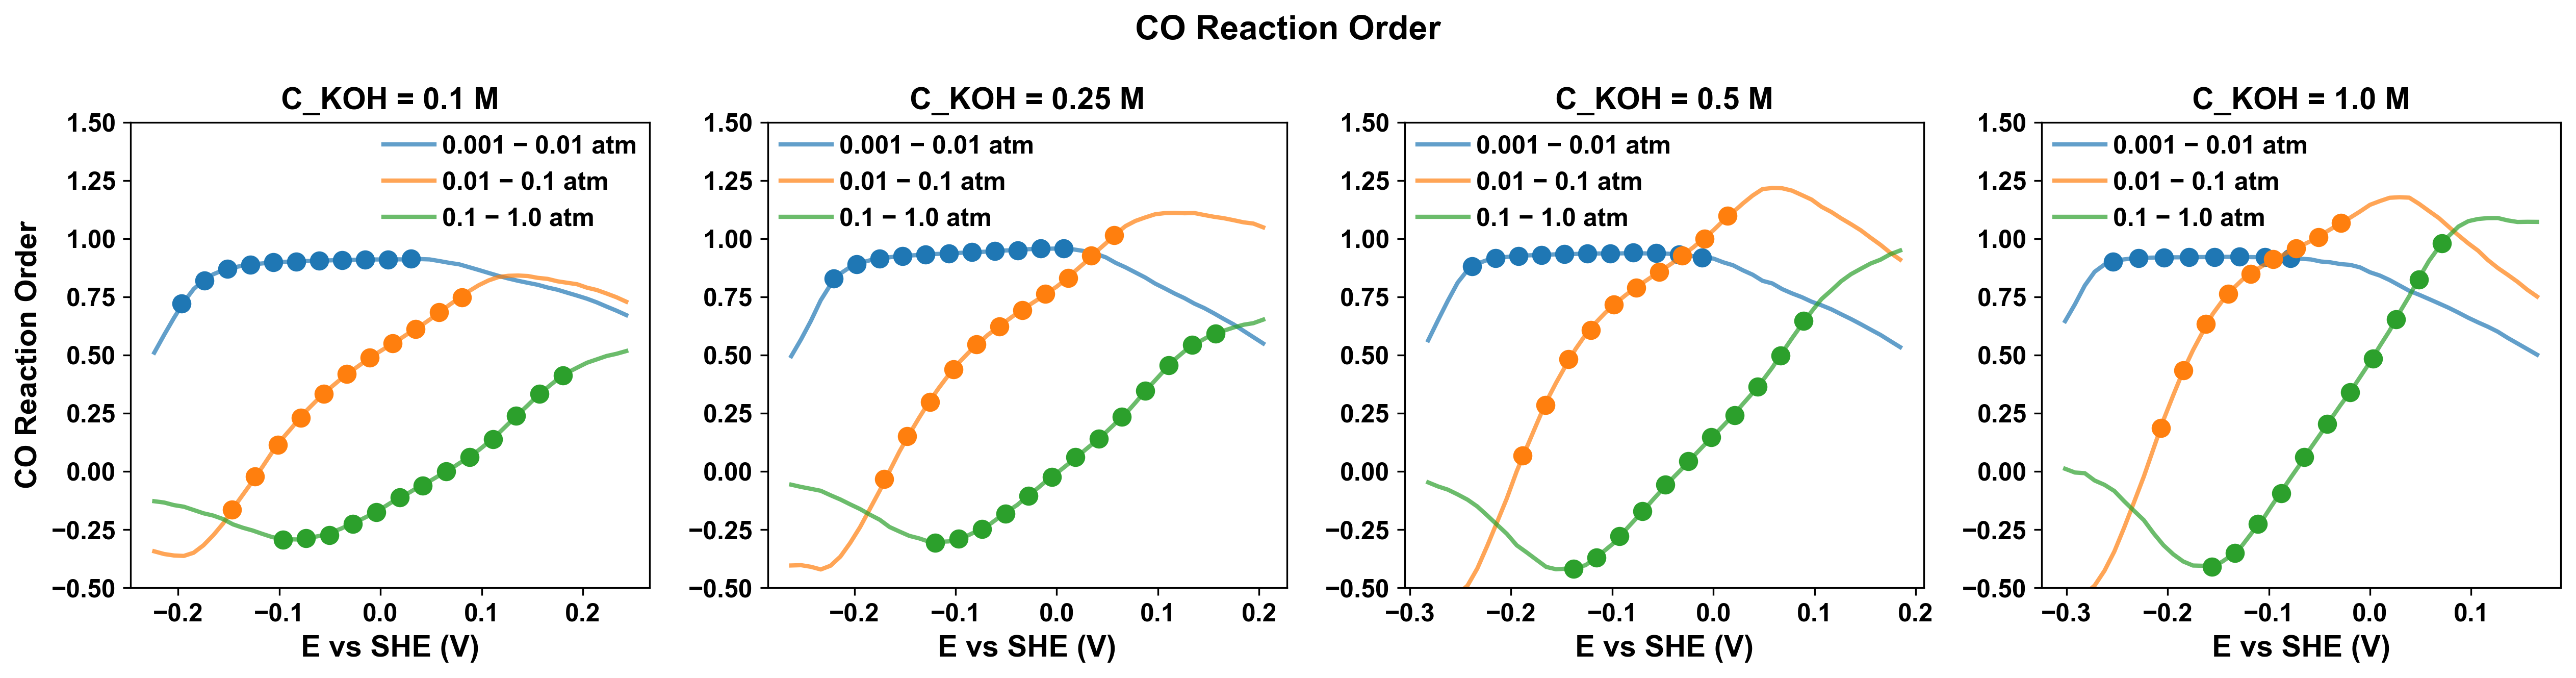

In [14]:
# Block 12: Plotting delta_CO

# --- Plot 1: 2x2 Publication Style (5.0 x 4.5) ---
fig = plt.figure(figsize=(5.0, 4.5), dpi=300)
for i, target_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(2, 2, i + 1)
    for (C_KOH, P_CO) in conditions_delta_CO:
        if C_KOH == target_KOH:
            condition = (C_KOH, P_CO)
            
            E = untruncated_data[condition]['shared_E_CO']
            delta_CO = untruncated_data[condition]['delta_CO']
            
            # Find the next P_CO for the label
            idx = int(np.where(P_CO_list == P_CO)[0][0])
            P_CO_2 = P_CO_list[idx + 1]
            
            line = ax.plot(E, delta_CO, label=f'{P_CO} - {P_CO_2} atm', linewidth=1.2)
            
            # Todd's discrete points
            if condition in delta_CO_todd and not delta_CO_todd[condition].empty:
                E_todd = delta_CO_todd[condition]['E']
                delta_CO_todd_val = delta_CO_todd[condition]['delta_CO']
                ax.plot(E_todd, delta_CO_todd_val, 'o', markersize=4, color=line[0].get_color())
                
    # 5% floating margin
    span = 1.5 - (-0.5)
    margin = 0.05 * span
    ax.set_yticks([-0.5, 0.0, 0.5, 1.0, 1.5])
    ax.set_ylim(-0.5 - margin, 1.5 + margin)
    ax.tick_params(axis='both', labelsize=8)
    
    # Share axes visually by hiding inner tick labels
    if i < 2: ax.tick_params(labelbottom=False)
    if i % 2 != 0: ax.tick_params(labelleft=False)
    
    # Legend only in the first plot
    if i == 0:
        ax.legend(fontsize=10, frameon=False, loc='upper left')

plt.tight_layout(pad=0.5)
plt.show()


# --- Plot 2: 1x4 Exploration Style (17 x 4.5) ---
fig = plt.figure(figsize=(17, 4.5))
fig.suptitle('CO Reaction Order', fontsize=16, fontweight='bold')
for i, target_KOH in enumerate(C_KOH_list):
    ax = plt.subplot(1, 4, i + 1) 
    ax.set_title(f'C_KOH = {target_KOH} M')
    for (C_KOH, P_CO) in conditions_delta_CO:
        if C_KOH == target_KOH:
            condition = (C_KOH, P_CO)
            
            E = untruncated_data[condition]['shared_E_CO']
            delta_CO = untruncated_data[condition]['delta_CO']
            
            idx = int(np.where(P_CO_list == P_CO)[0][0])
            P_CO_2 = P_CO_list[idx + 1]
            
            line, = ax.plot(E, delta_CO, label=f'{P_CO} - {P_CO_2} atm', alpha=0.7, linewidth=2)
            
            # Todd's discrete points
            if condition in delta_CO_todd and not delta_CO_todd[condition].empty:
                E_todd = delta_CO_todd[condition]['E']
                delta_CO_todd_val = delta_CO_todd[condition]['delta_CO']
                ax.plot(E_todd, delta_CO_todd_val, 'o', markersize=8, color=line.get_color())

    ax.legend()
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('E vs SHE (V)')
    if i == 0: ax.set_ylabel('CO Reaction Order')

plt.tight_layout()
plt.show()

In [15]:
import pickle 

# Save a dictionary containing BOTH so your modeling script has everything
export_data = {
    'truncated': experiments_interp,
    'untruncated': untruncated_data
}

with open(f'import_{alloy}_KOH.pkl', 'wb') as f:
    pickle.dump(export_data, f)